In [87]:
import re
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [88]:
sns.set_theme(style="whitegrid", context="talk")

In [89]:
OUT_DIR = "S01"
os.makedirs(OUT_DIR, exist_ok=True)

In [90]:
BASE_DIR = Path.cwd()  # Current directory of the running file
DATA_DIR = BASE_DIR.parent / "T03_af"
CURRENT_DIR = BASE_DIR

In [91]:
with open(DATA_DIR / "S10_af_time_series.pkl", "rb") as f:
    data = pickle.load(f)

measurements = data["data"]
infos = pd.read_excel(DATA_DIR / "S16_af_info.xlsx")

In [92]:
infos

,sample_no,DynoWare,Path,Filename,Config ID,Setup ID,Manipulated,Filename 1,Filename 2,Date,...,LOC4_idx,LOC5_time,LOC5_Fz,LOC5_idx,LOC6_time,LOC6_Fz,LOC6_idx,LOC7_time,LOC7_Fz,LOC7_idx
0,1,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 1.dwd,Sample 1.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,10356,118.560000,1.955412,11856,133.560000,1.987789,13356,148.560000,2.062822,14856
1,2,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 2.dwd,Sample 2.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,10762,122.620000,1.798143,12262,137.620000,1.866014,13762,152.620000,1.937174,15262
2,3,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 3.dwd,Sample 3.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,11324,128.240000,1.864614,12824,143.240000,1.914791,14324,158.240000,1.938849,15824
3,4,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 4.dwd,Sample 4.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,9235,105.211429,1.884570,10521,118.068571,1.940492,11807,130.925714,2.004096,13093
4,5,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 5.dwd,Sample 5.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,9816,111.021429,1.482512,11102,123.878571,1.501797,12388,136.735714,1.523190,13674
5,6,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 6.dwd,Sample 6.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,9937,112.231429,1.391324,11223,125.088571,1.414208,12509,137.945714,1.392280,13795
6,7,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 7.dwd,Sample 7.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,8324,94.490000,1.727454,9449,105.740000,1.824198,10574,116.990000,1.864062,11699
7,8,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 8.dwd,Sample 8.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,8965,100.900000,1.458888,10090,112.150000,1.585516,11215,123.400000,1.611573,12340
8,9,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 9.dwd,Sample 9.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,9662,107.870000,1.663417,10787,119.120000,1.745621,11912,130.370000,1.794847,13037
9,10,Version 3.2.2.0,D:\Parn (paper ML Weld)\Post welding\,Sample 10.dwd,Sample 10.cfg,0,0,NaN,NaN,"Wednesday, January 01, 2025",...,10032,115.320000,1.520111,11532,130.320000,1.587619,13032,145.320000,1.711081,14532


In [93]:
# Calculate value of location
rolling_window_fz = 30  # Less smooth for Fz due to less noise and fluctuations
rolling_window_default = (
    60  # Smoother for Fx, Fy, Mz due to more noise and fluctuations
)
df_arr = []
for sample_no in infos["sample_no"].values:
    # Load data from dataframes
    measure = measurements.loc[measurements["sample_no"] == sample_no].reset_index(
        drop=True
    )
    info = infos[infos["sample_no"] == sample_no].iloc[0]
    measure.set_index("Time", inplace=True)
    cols_loc_idx = [f"LOC{i}_idx" for i in range(1, 8)]
    cols_loc_time = [f"LOC{i}_time" for i in range(1, 8)]
    loc_time_idxs = info[cols_loc_idx].values
    loc_time = info[cols_loc_time].values

    fx = measure["Fx"].rolling(window=rolling_window_default).mean()
    fy = measure["Fy"].rolling(window=rolling_window_default).mean()
    fz = measure["Fz"].rolling(window=rolling_window_fz).mean()  # Less smooth for Fz
    mz = measure["Mz"].rolling(window=rolling_window_default).mean()

    loc_fx = fx.iloc[loc_time_idxs].values
    loc_fy = fy.iloc[loc_time_idxs].values
    loc_fz = fz.iloc[loc_time_idxs].values
    loc_mz = mz.iloc[loc_time_idxs].values

    _df = pd.DataFrame(
        {
            "sample_no": sample_no,
            "Location": [i for i in range(1, 8)],
            "Fx": loc_fx,
            "Fy": loc_fy,
            "Fz": loc_fz,
            "Mz": loc_mz,
            "loc_idx": loc_time_idxs,
            "loc_time": loc_time,
        }
    )
    df_arr.append(_df)
info_locs = pd.concat(df_arr).reset_index(drop=True)
info_locs

,sample_no,Location,Fx,Fy,Fz,Mz,loc_idx,loc_time
0,1,1,-0.088757,0.147307,1.244326,1.309648,5856,58.56
1,1,2,-0.033657,0.198459,1.625039,4.507891,7356,73.56
2,1,3,-0.044528,0.287103,1.799653,5.103177,8856,88.56
3,1,4,-0.027141,0.272358,1.882699,5.751634,10356,103.56
4,1,5,-0.033442,0.258838,1.955412,6.014084,11856,118.56
...,...,...,...,...,...,...,...,...
373,54,3,-0.071405,0.206050,1.352393,5.641014,8631,86.31
374,54,4,-0.081614,0.242535,1.529089,6.861035,9756,97.56
375,54,5,-0.067108,0.248853,1.657737,7.920559,10881,108.81
376,54,6,-0.068625,0.262266,1.712860,8.895459,12006,120.06


## Figure


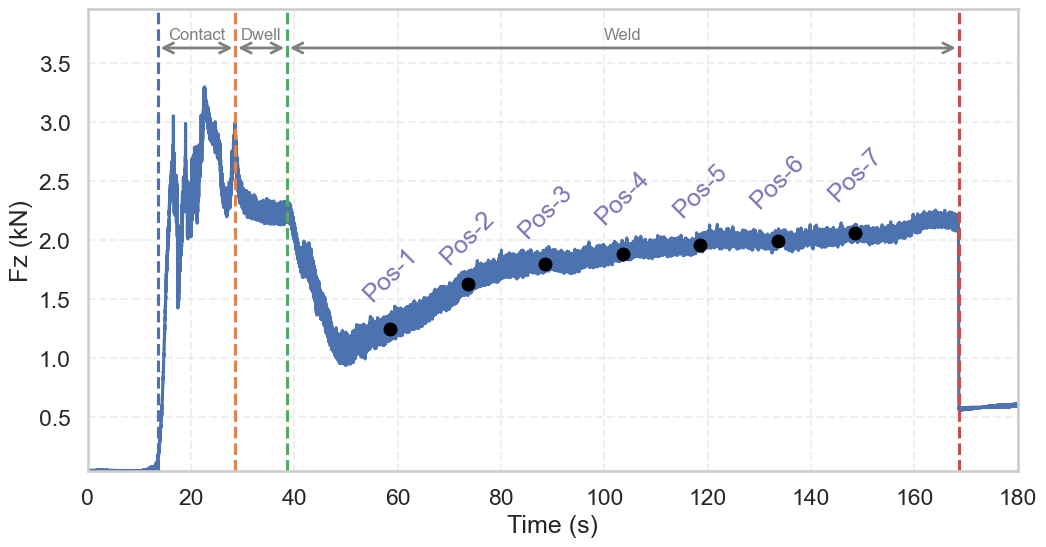

In [94]:
sample_no = 1
# measure_type = "Fx"
# measure_type = "Fy"
measure_type = "Fz"
# measure_type = "Mz"


cp = sns.color_palette(n_colors=5)
measure = measurements.loc[measurements["sample_no"] == sample_no].reset_index(
    drop=True
)
info = infos[infos["sample_no"] == sample_no].iloc[0]
info_loc = info_locs[info_locs["sample_no"] == sample_no][
    ["Location", "loc_time", "loc_idx", measure_type]
]
measure.set_index("Time", inplace=True)
af = measure[measure_type]
R = info["R"]
D = info["D"]
W = info["W"]
loc_vals = info_loc[measure_type].values
loc_idxs = info_loc["loc_idx"].values
loc_times = info_loc["loc_time"].values


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(af.index, af.values, label=f"{measure_type}")
ax.axvline(
    info["contact_time_start"], color=cp[0], linestyle="--", label="Contact Start"
)
ax.axvline(info["dwell_time_start"], color=cp[1], linestyle="--", label="Dwell Start")
ax.axvline(info["dwell_time_end"], color=cp[2], linestyle="--", label="Dwell End")
ax.axvline(info["weld_time_end"], color=cp[3], linestyle="--", label="Weld End")

for i in range(1, 8):
    loc_idx = loc_idxs[i - 1]
    loc_val = loc_vals[i - 1]
    loc_time = loc_times[i - 1]
    # ax.axvline(loc_time, color=cp[4], linestyle="--")
    ax.text(
        loc_time,
        af.iloc[loc_idx] + af.max() * 0.15,
        f"Pos-{i}",
        verticalalignment="center",
        horizontalalignment="center",
        color=cp[4],
        clip_on=True,
        rotation=45,
    )
    ax.plot(
        measure.index[loc_idx],
        loc_val,
        marker="o",
        color="black",
    )

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["contact_time_start"]
arrow_x_end = info["dwell_time_start"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.02, "Contact", horizontalalignment="center", color="gray", fontsize=12)

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["dwell_time_start"]
arrow_x_end = info["dwell_time_end"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.02, "Dwell", horizontalalignment="center", color="gray", fontsize=12)

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["dwell_time_end"]
arrow_x_end = info["weld_time_end"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.02, "Weld", horizontalalignment="center", color="gray", fontsize=12)

# ax.set_title(f"Value: {measure_type}, Sample No: {sample_no}, R={R}, D={D}, W={W}")
ax.set_ylim(af.min() * 1.5, af.max() * 1.2)
ax.set_xlim(0, af.index.max())
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"{measure_type} (kN)")
plt.grid(True, which="major", linestyle="--", alpha=0.3)
# ax.legend()
plt.show()

fig.savefig(f"{measure_type}_sample{sample_no}.png", dpi=300, bbox_inches="tight")


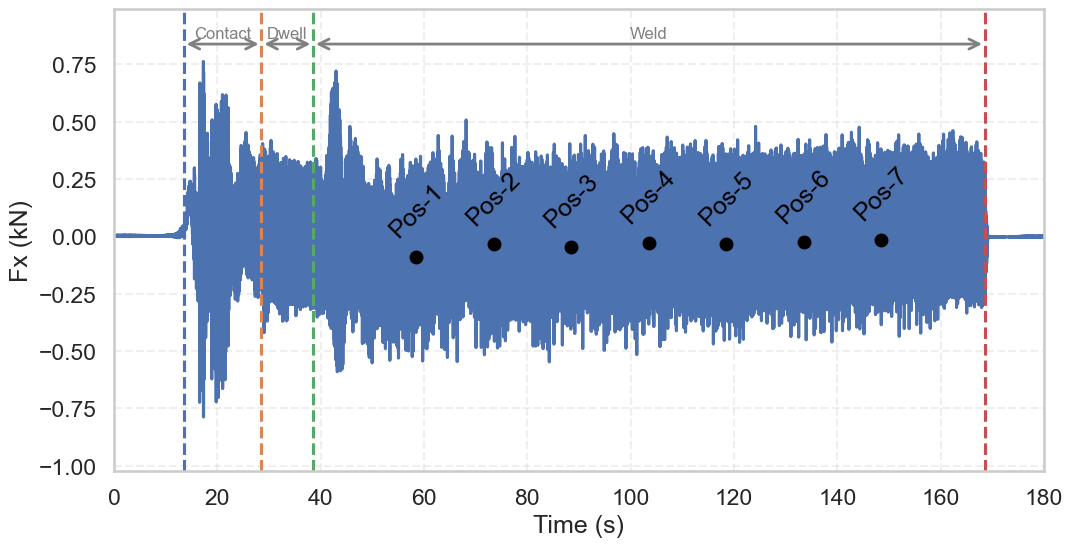

In [109]:
sample_no = 1
measure_type = "Fx"
# measure_type = "Fy"
# measure_type = "Fz"
# measure_type = "Mz"


cp = sns.color_palette(n_colors=5)
measure = measurements.loc[measurements["sample_no"] == sample_no].reset_index(
    drop=True
)
info = infos[infos["sample_no"] == sample_no].iloc[0]
info_loc = info_locs[info_locs["sample_no"] == sample_no][
    ["Location", "loc_time", "loc_idx", measure_type]
]
measure.set_index("Time", inplace=True)
af = measure[measure_type]
R = info["R"]
D = info["D"]
W = info["W"]
loc_vals = info_loc[measure_type].values
loc_idxs = info_loc["loc_idx"].values
loc_times = info_loc["loc_time"].values


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(af.index, af.values, label=f"{measure_type}")
ax.axvline(
    info["contact_time_start"], color=cp[0], linestyle="--", label="Contact Start"
)
ax.axvline(info["dwell_time_start"], color=cp[1], linestyle="--", label="Dwell Start")
ax.axvline(info["dwell_time_end"], color=cp[2], linestyle="--", label="Dwell End")
ax.axvline(info["weld_time_end"], color=cp[3], linestyle="--", label="Weld End")

for i in range(1, 8):
    loc_idx = loc_idxs[i - 1]
    loc_val = loc_vals[i - 1]
    loc_time = loc_times[i - 1]
    # ax.axvline(loc_time, color=cp[4], linestyle="--")
    ax.text(
        loc_time,
        # af.iloc[loc_idx] + af.max() * 0.5,
        # 0.11,
        loc_val + 0.2,
        f"Pos-{i}",
        verticalalignment="center",
        horizontalalignment="center",
        # color=cp[4],
        color="black",
        clip_on=True,
        rotation=45,
    )
    ax.plot(
        measure.index[loc_idx],
        loc_val,
        marker="o",
        color="black",
    )

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["contact_time_start"]
arrow_x_end = info["dwell_time_start"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.03, "Contact", horizontalalignment="center", color="gray", fontsize=12)

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["dwell_time_start"]
arrow_x_end = info["dwell_time_end"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.03, "Dwell", horizontalalignment="center", color="gray", fontsize=12)

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["dwell_time_end"]
arrow_x_end = info["weld_time_end"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.03, "Weld", horizontalalignment="center", color="gray", fontsize=12)

# ax.set_title(f"Value: {measure_type}, Sample No: {sample_no}, R={R}, D={D}, W={W}")
ax.set_ylim(af.min() * 1.3, af.max() * 1.3)
ax.set_xlim(0, af.index.max())
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"{measure_type} (kN)")
plt.grid(True, which="major", linestyle="--", alpha=0.3)
# ax.legend()
plt.show()

fig.savefig(f"{measure_type}_sample{sample_no}.png", dpi=300, bbox_inches="tight")


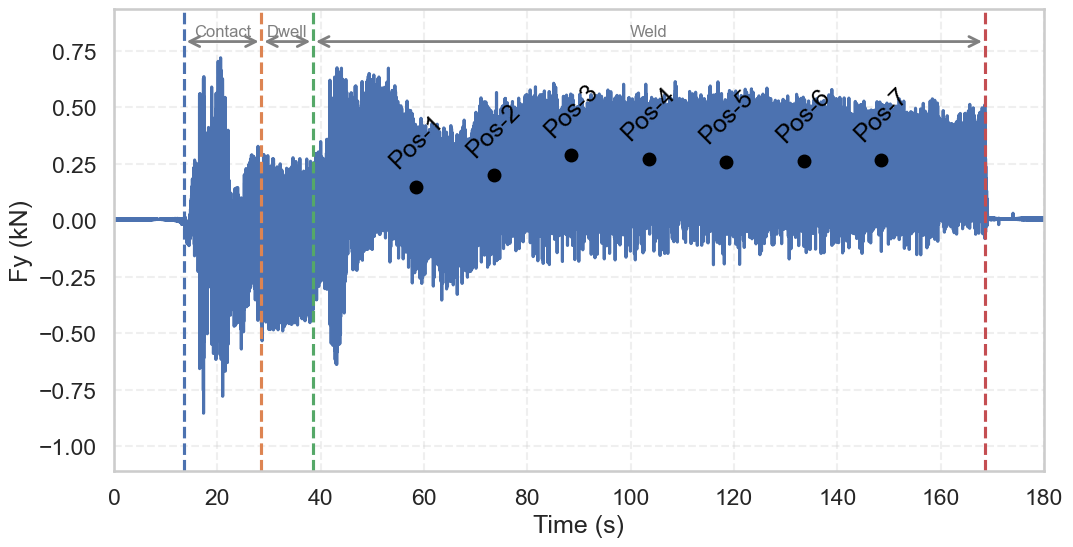

In [107]:
sample_no = 1
# measure_type = "Fx"
measure_type = "Fy"
# measure_type = "Fz"
# measure_type = "Mz"


cp = sns.color_palette(n_colors=5)
measure = measurements.loc[measurements["sample_no"] == sample_no].reset_index(
    drop=True
)
info = infos[infos["sample_no"] == sample_no].iloc[0]
info_loc = info_locs[info_locs["sample_no"] == sample_no][
    ["Location", "loc_time", "loc_idx", measure_type]
]
measure.set_index("Time", inplace=True)
af = measure[measure_type]
R = info["R"]
D = info["D"]
W = info["W"]
loc_vals = info_loc[measure_type].values
loc_idxs = info_loc["loc_idx"].values
loc_times = info_loc["loc_time"].values


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(af.index, af.values, label=f"{measure_type}")
ax.axvline(
    info["contact_time_start"], color=cp[0], linestyle="--", label="Contact Start"
)
ax.axvline(info["dwell_time_start"], color=cp[1], linestyle="--", label="Dwell Start")
ax.axvline(info["dwell_time_end"], color=cp[2], linestyle="--", label="Dwell End")
ax.axvline(info["weld_time_end"], color=cp[3], linestyle="--", label="Weld End")

for i in range(1, 8):
    loc_idx = loc_idxs[i - 1]
    loc_val = loc_vals[i - 1]
    loc_time = loc_times[i - 1]
    # ax.axvline(loc_time, color=cp[4], linestyle="--")
    ax.text(
        loc_time,
        # af.iloc[loc_idx] + 0.1,
        loc_val + 0.2,
        # 0.5,
        f"Pos-{i}",
        verticalalignment="center",
        horizontalalignment="center",
        # color=cp[4],
        color="black",
        clip_on=True,
        rotation=45,
    )
    ax.plot(
        measure.index[loc_idx],
        loc_val,
        marker="o",
        color="black",
    )

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["contact_time_start"]
arrow_x_end = info["dwell_time_start"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.03, "Contact", horizontalalignment="center", color="gray", fontsize=12)

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["dwell_time_start"]
arrow_x_end = info["dwell_time_end"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.03, "Dwell", horizontalalignment="center", color="gray", fontsize=12)

# Annotate horizontal line with arrows at both ends
arrow_x_start = info["dwell_time_end"]
arrow_x_end = info["weld_time_end"]
arrow_y = af.max() * 1.1
ax.annotate(
    "",
    xy=(arrow_x_start, arrow_y),
    xytext=(arrow_x_end, arrow_y),
    arrowprops=dict(arrowstyle="<->", color="gray", lw=2),
)
# Add text at the mid point of the horizontal line
mid_x = (arrow_x_start + arrow_x_end) / 2
ax.text(mid_x, arrow_y * 1.03, "Weld", horizontalalignment="center", color="gray", fontsize=12)

# ax.set_title(f"Value: {measure_type}, Sample No: {sample_no}, R={R}, D={D}, W={W}")
ax.set_ylim(af.min() * 1.3, af.max() * 1.3)
ax.set_xlim(0, af.index.max())
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"{measure_type} (kN)")
plt.grid(True, which="major", linestyle="--", alpha=0.3)
# ax.legend()
plt.show()

fig.savefig(f"{measure_type}_sample{sample_no}.png", dpi=300, bbox_inches="tight")
